# Lesson Plan: Addressing Inequality in Nairobi’s Primary Education Access
### Lecturer’s Name : Christine Kirimi
### Date : 4/30/2025
### Course : Introduction to Data-Driven Decision Making
### Duration : 20 minutes
### Subject/Unit : Data Analysis for Public Policy
### Level : Beginner / Early Career Analysts

### Aims of the Lesson
•	Introduce learners to using data for decision making.

•	Explore practical applications of data analysis using real-world education data.

•	Demonstrate how merging datasets, visualizing data, and deriving ratios can uncover infrastructure gaps.

### Lesson Objectives
•	Understand how they can use data for decision making.

•	Learn how they can do data cleaning and exploratory data Analysis.

•	Create and interpret visualizations that highlight disparities in school distribution.

•	Generate actionable insights from real education data.

### Assumed Prior Knowledge
•   Basic understanding of what a dataset is.

•   Familiarity with Jupyter Notebook environments (no coding required).

•   Awareness of public school systems and local infrastructure challenges.

### Resources
•	Screen with live Jupyter Notebook

•	Nairobi Schools CSV + Census Data

•	Nairobi Constituency GeoJSON for mapping

•	PowerPoint summary slide (optional)



# Improving Access to Quality Education in Nairobi
## INTRODUCTION
This analysis aims to identify and address disparities in access to quality primary education across Nairobi County. Leveraging data from the Education Facilities dataset and the Kenya Population and Housing Census, this project focuses on:

1. Mapping Education Facilities: Analyzing the geographic distribution of primary schools.

2. Evaluating Demographic Disparities: Assessing population density and accessibility to education infrastructure.

3. Identifying Vulnerabilities: Highlighting underserved areas and overcrowded schools.

4. Proposing Actionable Recommendations: Guiding investment decisions to ensure equitable resource allocation.

The findings will provide data-driven insights to help the Nairobi County Education Office prioritize investments and improve educational outcomes, aligning with Sustainable Development Goal 4: "Ensure inclusive and equitable quality education for all."


### ASSUMPTIONS
 1. Sub-counties in the Census dataset were 
assumed to be similar to the constituencies 
in Education Facilities Dataset
 2. It was assumed that the higher the general 
population per area also the higher the 
student population in the area

### DATA PREPARATION

In [2]:
# Importing necessary libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
import folium
from folium.plugins import HeatMap

In [3]:
# Load the datasets
education_data_path = 'kenya_primary_schools.csv'
census_data_path = 'Nairobi_city_subcounty_data.csv'

In [4]:
# Load data into Pandas DataFrames
kenya_df = pd.read_csv(education_data_path)
census_df = pd.read_csv(census_data_path)

### DATA CLEANING

We are selecting only the schools in Nairobi by checking the District column.
This code looks through each row, and if it finds the word Nairobi in the District name, it keeps that row.
It doesn’t matter if the word is in uppercase or lowercase — and it safely skips any missing entries.
We then save those Nairobi schools into a new dataset called education_df.

case=False	Makes the search not case-sensitive — so it will find "nairobi", "Nairobi", or "NAIROBI".

na=False	Prevents errors if some rows are empty or missing values (it just skips them).

In [5]:
# Filter data for Nairobi County
education_df = kenya_df[kenya_df['District'].str.contains("NAIROBI", case=False, na=False)]

To prepare my dataset, I needed to identify and replace all blank entries with a standardized missing value (NaN). I used a regex-based replacement to capture cells with no content or only spaces, which pandas wouldn’t catch otherwise. This ensures I can handle missing values consistently during cleaning and analysis.

r'^\s*$' is a regular expression matching any cell with only whitespace or completely blank.

np.nan replaces these with a proper missing value.

regex=True tells pandas to treat the pattern as a regular expression.

inplace=True applies changes directly to the dataframe.

In [6]:
import numpy as np
# Replace blank cells with NaN
education_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
census_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7764\3871286157.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  education_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)


I began by exploring the structure of my datasets using .info(). This provided a quick overview of the number of entries, column types, and missing values. It helped me assess data quality early, informing my cleaning steps like handling missing values and standardizing data types.

education_df.info() gives a summary of your education dataset.

census_df.info() gives a summary of your census dataset.

By wrapping it with print(), you format the output nicely and label it ("Education Data Overview:", "Census Data Overview:") so the outputs don't mix.

The "\n" simply adds a newline to make the console output easier to read (a blank line after each block).

In [7]:
# Display basic information about the datasets
print("Education Data Overview:")
print(education_df.info(), "\n")
print("Census Data Overview:")
print(census_df.info(), "\n")

Education Data Overview:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1241 entries, 587 to 22994
Data columns (total 38 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   X            1241 non-null   float64
 1   Y            1241 non-null   float64
 2   FID          1241 non-null   int64  
 3   Name_of_Sc   1241 non-null   object 
 4   Level_       1241 non-null   object 
 5   Status       1241 non-null   object 
 6   SchSponsor   1240 non-null   object 
 7   Type1        1090 non-null   object 
 8   Type2        1089 non-null   object 
 9   Type3        1241 non-null   object 
 10  PupilTeach   1241 non-null   float64
 11  ClassrmRat   1241 non-null   float64
 12  ToiletRati   1241 non-null   float64
 13  No_Classrm   1241 non-null   float64
 14  BoysToilet   1241 non-null   float64
 15  GirlsToilet  1241 non-null   float64
 16  TeachersTo   1241 non-null   float64
 17  TotalToile   1241 non-null   float64
 18  TotalBoys    1241 no

There was a small but critical typo in the column name 'Costituenc', which should be 'Constituency'. I corrected it to ensure a smooth merge with the census dataset later. It's important that column names match exactly when joining datasets

In [8]:
education_df = education_df.rename(columns={"Costituenc" : "Constituency"})

To assess data quality, I used .isnull().sum() to count missing values in each column. This helps me identify which columns may need cleaning or imputation before analysis. It’s a standard but critical first step in preprocessing.

In [9]:
# Clean and preprocess the data
# Checking for missing values
education_missing = education_df.isnull().sum()
census_missing = census_df.isnull().sum()

I used print() to clearly output the number of missing values in each dataset. This helps me visually inspect the data and communicate which columns may require attention before analysis or merging.

For example, if 'Constituency' or 'Longitude' had missing values, I’d either drop those rows if they’re few or investigate further if they affect merging or mapping.

In [10]:
print("Missing Values in Education Data:\n", education_missing)
print("Missing Values in Census Data:\n", census_missing)

Missing Values in Education Data:
 X                 0
Y                 0
FID               0
Name_of_Sc        0
Level_            0
Status            0
SchSponsor        1
Type1           151
Type2           152
Type3             0
PupilTeach        0
ClassrmRat        0
ToiletRati        0
No_Classrm        0
BoysToilet        0
GirlsToilet       0
TeachersTo        0
TotalToile        0
TotalBoys         0
TotalGirls        0
TotalEnrol        0
GO_KTSC_M         0
GOK_TSC_F         0
authorityM        0
authorityF        0
PTA_BOG_M         0
PTA_BOG_F         0
OthersM           0
OthersF           0
NoTeaching        0
NonTeachin        0
Province          0
District          0
Division          0
Location          0
Constituency      0
Latitude          0
Longitude         0
dtype: int64
Missing Values in Census Data:
 Constituency    0
Total_Pop       0
Male_Pop        0
Femal_Pop       0
Sex_Ratio       0
Intersex_Pop    0
Land_Area       0
Pop_Density     0
HH_No           

## EXPLORATORY DATA ANALYSIS

I used display() to visually inspect the dataset in the notebook. It’s a useful way to verify if cleaning steps like renaming or replacing blanks with NaNs were successful, and to get an intuitive sense of what the data looks like.
It helps me validate column names, formats, and missing value replacements before moving on to merging or analysis.


In [11]:
display(education_df)

,X,Y,FID,Name_of_Sc,Level_,Status,SchSponsor,Type1,Type2,Type3,...,OthersF,NoTeaching,NonTeachin,Province,District,Division,Location,Constituency,Latitude,Longitude
587,36.85,-1.26,10588,BRIGHT ACADEMY PR,PRIMARY SCHOOL,PRIVATE,NGO/CBO,MIXED,DAY ONLY,ORDINARY,...,0.0,0.0,1.0,NAIROBI,NAIROBI,STAREHE,MATHARE,STAREHE,-1.26,36.85
13645,36.91,-1.27,8646,DIWOPA PRI SCH,PRIMARY SCHOOL,PRIVATE,PRIVATE INDIVIDUAL,NaN,NaN,ORDINARY,...,0.0,0.0,0.0,NAIROBI,NAIROBI,EMBAKASI,KAYOLE,EMBAKASI,-1.27,36.91
20270,36.75,-1.28,21271,GATINA PRI SCH,PRIMARY SCHOOL,PUBLIC,LOCAL GOVERNMENT AUTHORITY,MIXED,DAY ONLY,ORDINARY,...,0.0,3.0,1.0,NAIROBI,NAIROBI,DAGORETTI,KAWANGWARE,DAGORETTI,-1.28,36.75
20276,36.76,-1.27,21277,MUGWAM EDUC CENTRE PRI SCHOOL,PRIMARY SCHOOL,PRIVATE,PRIVATE INDIVIDUAL,MIXED,DAY ONLY,ORDINARY,...,2.0,1.0,2.0,NAIROBI,NAIROBI,DAGORETTI,KAWANGWARE,DAGORETTI,-1.27,36.76
20282,36.76,-1.27,21283,MUGWAM EDUCATION CENTRE (PRI) SCH,PRIMARY SCHOOL,PRIVATE,PRIVATE INDIVIDUAL,MIXED,DAY ONLY,ORDINARY,...,2.0,1.0,2.0,NAIROBI,NAIROBI,DAGORETTI,KAWANGWARE,DAGORETTI,-1.27,36.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22986,36.88,-1.23,22987,KID MEGATON SCHOOL - PRI,PRIMARY SCHOOL,PRIVATE,PRIVATE INDIVIDUAL,NaN,NaN,ORDINARY,...,0.0,0.0,0.0,NAIROBI,NAIROBI,KASARANI,KASARANI,KASARANI,-1.23,36.88
22988,36.87,-1.23,22989,GOSPEL ASSEMBLY CHRISTIAN ACADEMY,PRIMARY SCHOOL,PRIVATE,RELIGIOUS ORGANIZATION,MIXED,DAY ONLY,ORDINARY,...,0.0,5.0,2.0,NAIROBI,NAIROBI,KASARANI,ROYSAMBU,KASARANI,-1.23,36.87
22990,36.82,-1.28,22991,CATHOLIC PAROCHIAL PRI SCH,PRIMARY SCHOOL,PUBLIC,LOCAL GOVERNMENT AUTHORITY,MIXED,DAY ONLY,ORDINARY,...,0.0,3.0,3.0,NAIROBI,NAIROBI,STAREHE,STAREHE,STAREHE,-1.28,36.82
22992,36.82,-1.28,22993,MOI AVENUE PRI SCH,PRIMARY SCHOOL,PUBLIC,LOCAL GOVERNMENT AUTHORITY,MIXED,DAY ONLY,ORDINARY,...,0.0,9.0,0.0,NAIROBI,NAIROBI,STAREHE,STAREHE,STAREHE,-1.28,36.82


education_df['Constituency'].unique() extracts all the unique (non-repeating) values in the 'Constituency' column.

These are returned as a NumPy array.

Assigns them to the variable unique_values, and when run in a Jupyter Notebook, the final line (unique_values) displays them.

In [12]:
unique_values = education_df['Constituency'].unique()
unique_values

array(['STAREHE', 'EMBAKASI', 'DAGORETTI', 'KAMUKUNJI', 'MAKADARA',
       'WESTLANDS', 'KASARANI', 'LANGATA'], dtype=object)

This transforms your regular education_df into a GeoDataFrame, which is used for mapping and geospatial analysis.

gpd.points_from_xy(...) converts longitude (X) and latitude (Y) columns into point geometry for each school.

This adds a new column called geometry containing these points.

Specifies the CRS (spatial reference system).

EPSG:32637 = UTM Zone 37N, commonly used for Kenya/Uganda region mapping in meters.

Required for distance calculations, overlays, or exporting to maps.


In [13]:
# Exploratory Data Analysis (EDA)
# School Distribution by Location
education_gdf = gpd.GeoDataFrame(
    education_df, geometry=gpd.points_from_xy(education_df.X, education_df.Y)
)
education_gdf.crs = "EPSG:32637"  # Set coordinate reference system

After converting the dataset to a GeoDataFrame, I visualized the location of all primary schools in Nairobi. This scatter map helps us spot clusters, gaps, or uneven school distributions. It makes the analysis more intuitive and highlights spatial trends that summary tables might hide.

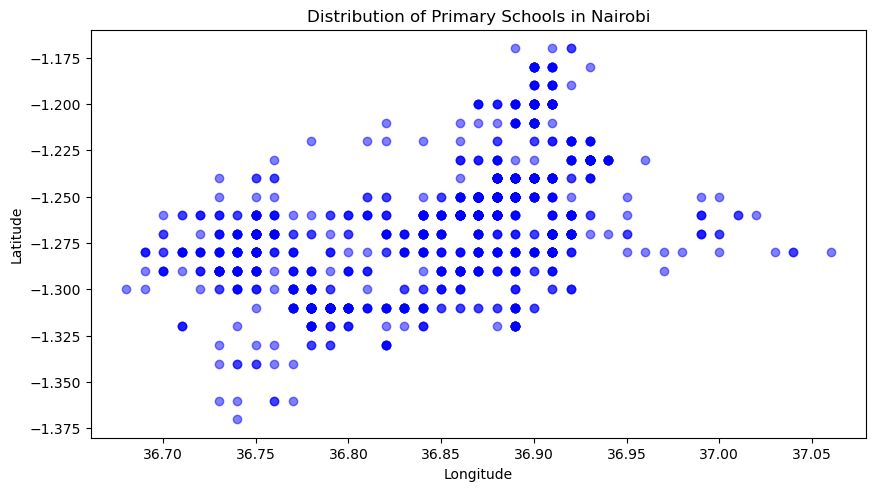

In [14]:
# Plot school locations
education_gdf.plot(marker='o', color='blue', alpha=0.5, figsize=(10, 10))
plt.title('Distribution of Primary Schools in Nairobi')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

I used .describe() on key infrastructure variables to understand the overall state of school resources. This gives me insight into things like average class size, how many students share a toilet, or where teacher shortages may be most severe.

In [15]:
# Assess basic statistics for key infrastructure variables in Nairobi County
nairobi_summary = education_df[['PupilTeach', 'ClassrmRat', 'ToiletRati', 
                                'No_Classrm', 'BoysToilet', 'GirlsToilet', 'TotalEnrol']].describe()
print(nairobi_summary)

        PupilTeach   ClassrmRat   ToiletRati   No_Classrm   BoysToilet  \
count  1241.000000  1241.000000  1241.000000  1241.000000  1241.000000   
mean     18.025302    19.678807    27.739968     9.010475     3.697824   
std      22.089667    19.008106    34.813212     8.413740     4.648767   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       4.900000     5.000000     3.000000     3.000000     1.000000   
50%      13.700000    15.700000    18.700000     8.000000     2.000000   
75%      25.400000    28.500000    39.000000    12.000000     5.000000   
max     289.000000   179.000000   440.500000    56.000000    26.000000   

       GirlsToilet   TotalEnrol  
count  1241.000000  1241.000000  
mean      4.481869   269.988719  
std       5.979389   402.687490  
min       0.000000     0.000000  
25%       1.000000    18.000000  
50%       2.000000   109.000000  
75%       6.000000   321.000000  
max      38.000000  2708.000000  


To assess overall infrastructure quality in Nairobi’s schools, I visualized the distribution of key metrics like pupil-teacher ratio and toilet ratio. These histograms show whether most schools are within acceptable ranges, or if a few are severely under-resourced. The spread, mean, and skew help identify areas of concern.
For instance, a long right tail on the pupil-teacher ratio indicates overcrowding in a subset of schools, which should be targeted for intervention.

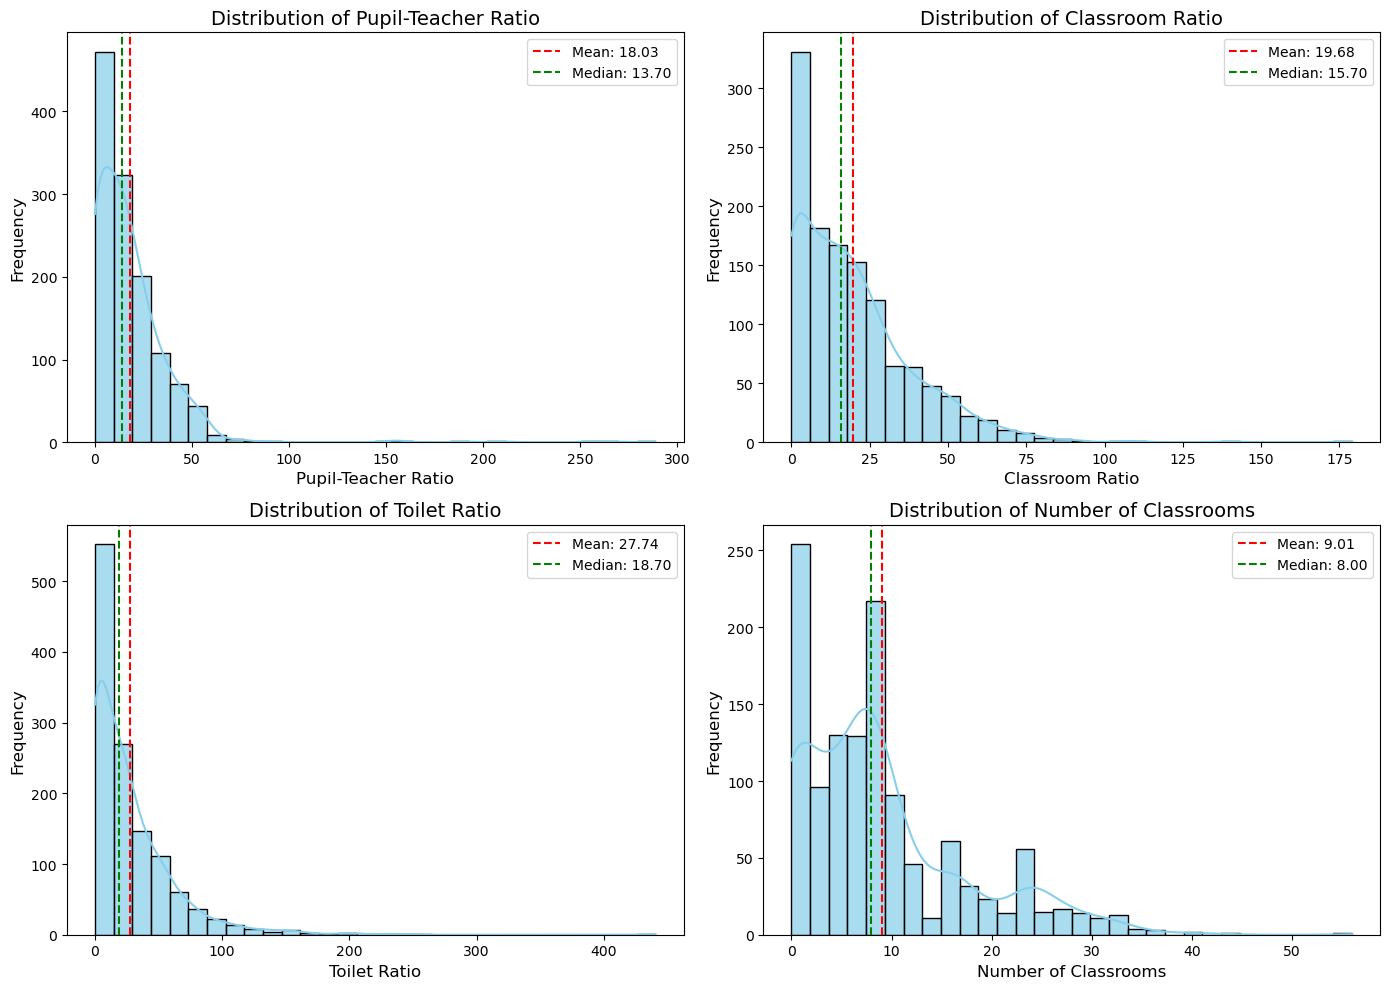

In [16]:
## Graphs showing distribution of infrastructure in the whole of Nairobi
# Define metrics to visualize
metrics = {
    'PupilTeach': 'Pupil-Teacher Ratio',
    'ClassrmRat': 'Classroom Ratio',
    'ToiletRati': 'Toilet Ratio',
    'No_Classrm': 'Number of Classrooms'
}

# Set up the figure
plt.figure(figsize=(14, 10))

# Loop through metrics to plot each distribution
for i, (metric, label) in enumerate(metrics.items(), start=1):
    plt.subplot(2, 2, i)
    sns.histplot(education_df[metric], kde=True, bins=30, color='skyblue', alpha=0.7)
    
    # Add title and labels
    plt.title(f'Distribution of {label}', fontsize=14)
    plt.xlabel(label, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    
    # Highlight mean and median
    mean = education_df[metric].mean()
    median = education_df[metric].median()
    plt.axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.2f}')
    plt.axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.2f}')
    plt.legend()

# Adjust layout and display
plt.tight_layout()
plt.show()



To understand the overall pressure on school infrastructure in Nairobi, I calculated the total population divided by the total number of schools. The result — a population-to-school ratio — gives a snapshot of how many people are served per school city-wide.

This complements the per-constituency metrics by providing a top-down view of school demand relative to population.

In [17]:
#3Student-to-School Ratio
# Assuming student_population is a column in census_df and number_of_schools is in education_df
total_population = census_df['Total_Pop'].sum()
total_schools = len(education_df)
print(total_schools)
population_to_school_ratio = total_population / total_schools

print(f"Population-to-School Ratio: {population_to_school_ratio:.2f}")

1241
Population-to-School Ratio: 3543.17


### MERGING THE TWO DATA SETS AND UNDERTAKING EDA

To analyze school infrastructure in context, I merged the education dataset with population data using the shared 'Constituency' column. I used a right join to ensure all school records were retained, and enriched them with census information where available.

In [18]:
#Merging the two Main Data sets
#Assuming we have ward/region-level data in both datasets
merged_df = pd.merge(census_df, education_df, on='Constituency', how='right')
merged_df
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1241 entries, 0 to 1240
Data columns (total 47 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Constituency  1241 non-null   object 
 1   Total_Pop     1241 non-null   int64  
 2   Male_Pop      1241 non-null   int64  
 3   Femal_Pop     1241 non-null   int64  
 4   Sex_Ratio     1241 non-null   float64
 5   Intersex_Pop  1241 non-null   int64  
 6   Land_Area     1241 non-null   float64
 7   Pop_Density   1241 non-null   int64  
 8   HH_No         1241 non-null   int64  
 9   HH_Size       1241 non-null   int64  
 10  X             1241 non-null   float64
 11  Y             1241 non-null   float64
 12  FID           1241 non-null   int64  
 13  Name_of_Sc    1241 non-null   object 
 14  Level_        1241 non-null   object 
 15  Status        1241 non-null   object 
 16  SchSponsor    1240 non-null   object 
 17  Type1         1090 non-null   object 
 18  Type2         1089 non-null 

To understand how different education and population factors relate, I created a correlation matrix and visualized it using a heatmap. This helped me explore whether high population density was associated with school overcrowding — for example, through variables like pupil-to-classroom or pupil-to-teacher ratios.

🔹 correlation_matrix = heatmap_data.corr()
Calculates the Pearson correlation between all pairs of selected columns.

The result is a symmetric matrix showing values from -1 (perfect negative) to +1 (perfect positive correlation).

🔹 Heatmap Plot
sns.heatmap(...) from Seaborn visually displays the correlation matrix:

annot=True: adds the numeric correlation values in each cell.

cmap='coolwarm': uses a color gradient (blue to red) for easier visual interpretation.

square=True: makes the heatmap cells square for symmetry.

The plot shows how strongly each variable is associated with the others.

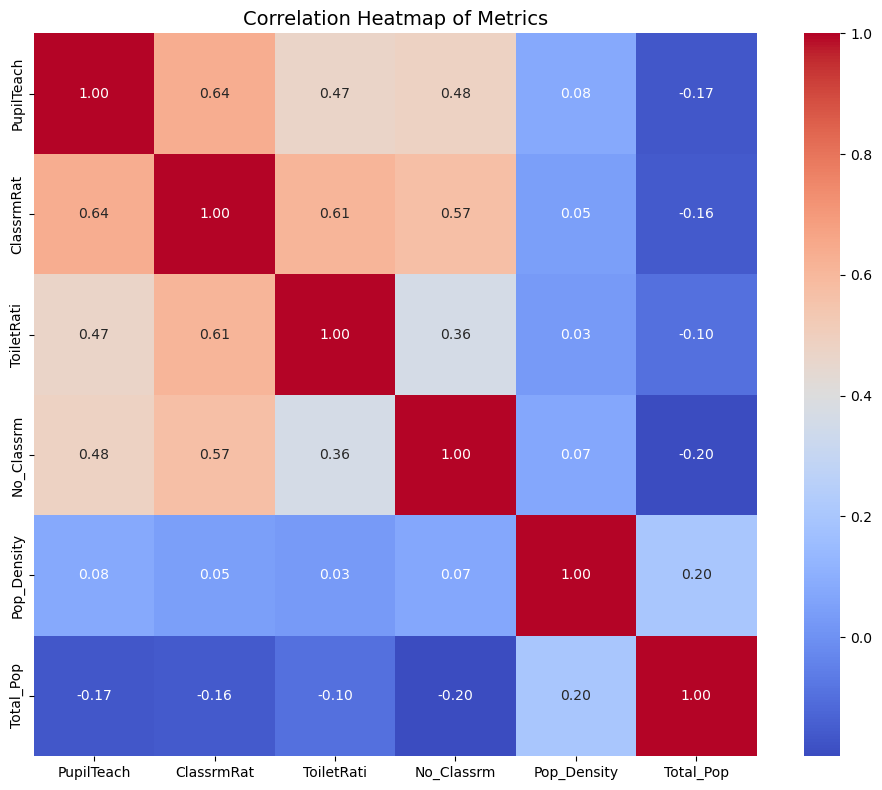

In [19]:
#Select relevant metrics for the heatmap
heatmap_data = merged_df[[
    'PupilTeach',
    'ClassrmRat',
    'ToiletRati',
    'No_Classrm',
    'Pop_Density',
    'Total_Pop',
]].dropna()

# Calculate correlation matrix
correlation_matrix = heatmap_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True
)
plt.title('Correlation Heatmap of Metrics', fontsize=14)
plt.tight_layout()
plt.show()


To compare school infrastructure across constituencies, I grouped the data and calculated average values for key indicators. I then used Seaborn to plot these metrics as grouped bar charts, allowing direct visual comparison between regions.

You select key numeric variables related to school infrastructure

Then group the dataset by 'Constituency' and calculate the mean of each metric.

Converts the grouped index (Constituency) back into a column so it can be used for plotting.

Reshapes the DataFrame so each row is a (Constituency, Metric, Value) combination.

This makes it suitable for Seaborn’s barplot(), which expects data in long format.

The hue='Constituency' separates the bars by region, allowing direct comparison.

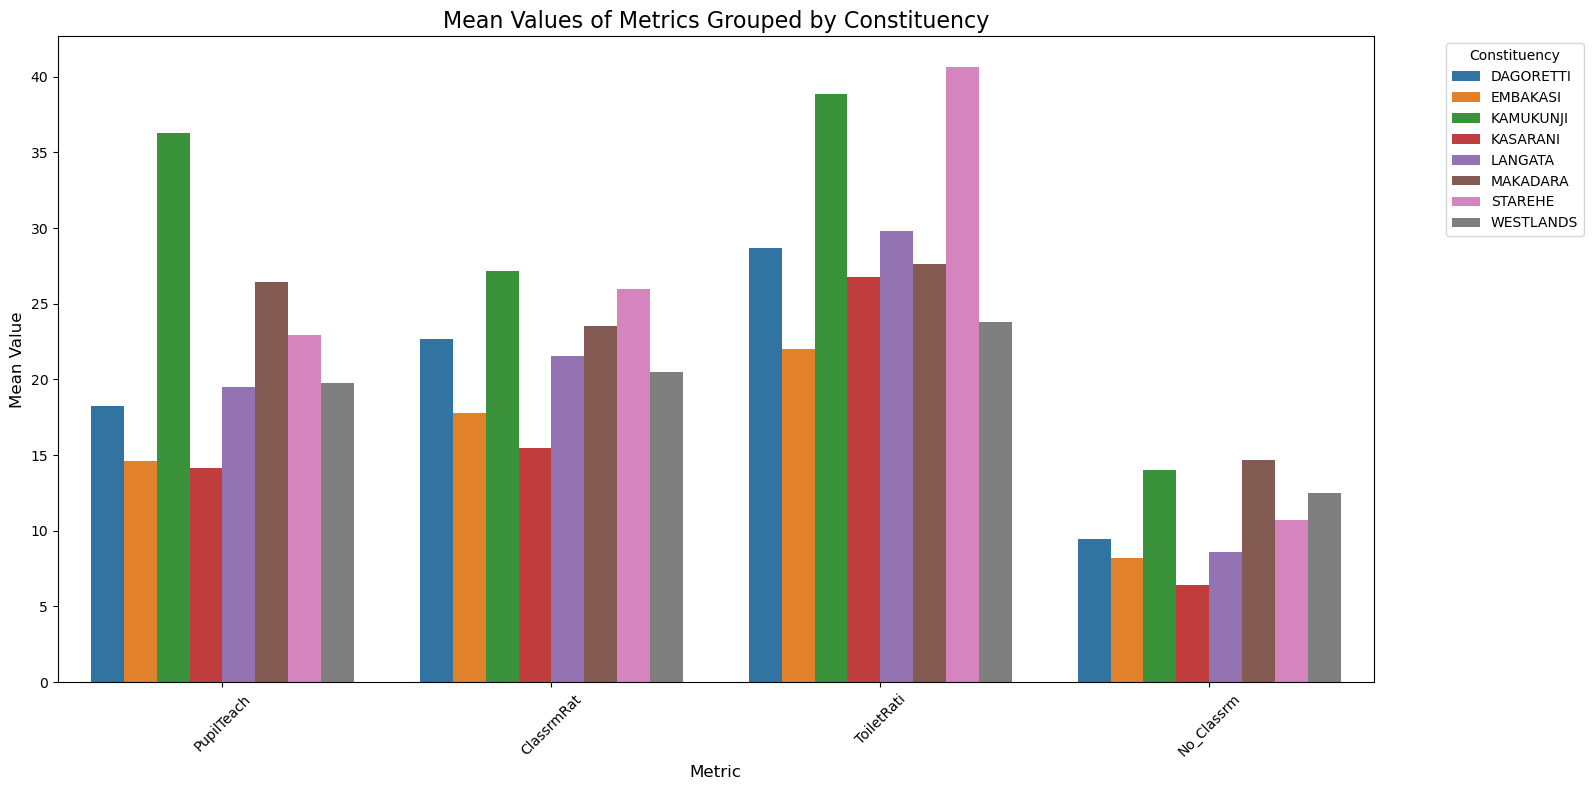

In [20]:

# Select relevant metrics and calculate mean per constituency
metrics = ['PupilTeach', 'ClassrmRat', 'ToiletRati', 'No_Classrm']
grouped_data = merged_df[['Constituency'] + metrics].groupby('Constituency').mean()

# Reset index for plotting
grouped_data = grouped_data.reset_index()

# Melt the DataFrame for easier plotting with Seaborn
plot_data = grouped_data.melt(
    id_vars='Constituency',
    var_name='Metric',
    value_name='Mean Value'
)

# Plot multiple bar graph
plt.figure(figsize=(16, 8))
sns.barplot(
    x='Metric',
    y='Mean Value',
    hue='Constituency',
    data=plot_data,
    palette='tab10'
)

# Add labels and title
plt.title('Mean Values of Metrics Grouped by Constituency', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Mean Value', fontsize=12)
plt.legend(title='Constituency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


I grouped the dataset by constituency and school sponsor to understand the distribution of public versus private schools. The stacked bar chart highlights disparities — for instance, some constituencies are heavily dependent on private institutions, which may limit access for lower-income families.
Groups the data by:'Constituency' – region/area 'SchSponsor' – type of school sponsor (e.g., Public, Private, Religious Organization)
.size() counts the number of schools in each combination.

.unstack() turns 'SchSponsor' into separate columns for each sponsor type.

fill_value=0 replaces missing values with zero (no schools of that type in that constituency).

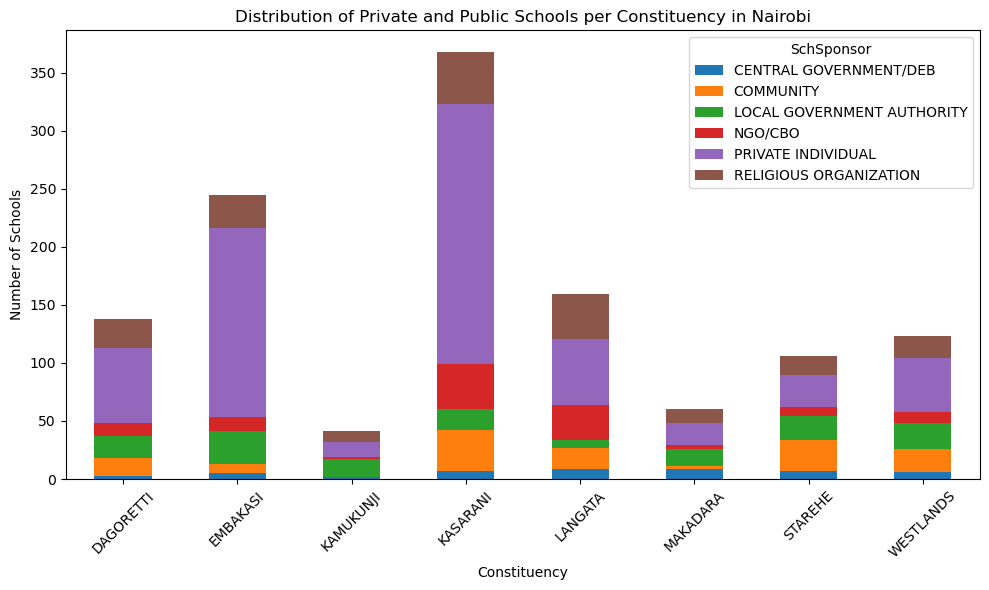

In [21]:
# Group by Constituency and Status, and count the occurrences
grouped = merged_df.groupby(['Constituency', 'SchSponsor']).size().unstack(fill_value=0)

# Plot the distribution
grouped.plot(kind='bar', stacked=True, figsize=(10, 6))

# Add labels and title
plt.title('Distribution of Private and Public Schools per Constituency in Nairobi')
plt.xlabel('Constituency')
plt.ylabel('Number of Schools')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

To compare access fairly, I calculated the number of schools per 1,000 residents in each constituency. This metric helps identify areas like Kamukunji that have high population but low school density — highlighting the need for infrastructure investment. This is a common approach in social data analysis — raw counts can hide disparities, so we normalize based on need or population.

Raw school counts are misleading: 50 schools in a small constituency is very different from 50 in a huge one.

Normalization (per 1,000 people) allows for equity analysis.

You can now highlight which areas are underserved even if they have many schools — because they also have many people.

In [22]:
# Calculate school-to-population ratio
school_distribution = merged_df.groupby("Constituency").agg(
    School_Count=("Name_of_Sc", "count"),
    Population_Total=("Total_Pop", "first")
).reset_index()
school_distribution["Schools_Per_1000_Pop"] = (school_distribution["School_Count"] / school_distribution["Population_Total"]) * 1000

After calculating the school-to-population ratio, I used .nlargest() and .nsmallest() to identify the top and bottom five constituencies. This let me clearly show which areas are best served and which are most in need of new school infrastructure.”

In [23]:
#Identify constituencies with the highest and lowest school-to-population ratio
highest_ratio = school_distribution.nlargest(5, "Schools_Per_1000_Pop")
print(highest_ratio)
lowest_ratio = school_distribution.nsmallest(5, "Schools_Per_1000_Pop")
print(lowest_ratio)

  Constituency  School_Count  Population_Total  Schools_Per_1000_Pop
4      LANGATA           159            197489              0.805108
6      STAREHE           106            210423              0.503747
3     KASARANI           368            780656              0.471398
7    WESTLANDS           124            308854              0.401484
0    DAGORETTI           138            434208              0.317820
  Constituency  School_Count  Population_Total  Schools_Per_1000_Pop
2    KAMUKUNJI            41            268276              0.152828
1     EMBAKASI           245            988808              0.247773
5     MAKADARA            60            189536              0.316563
0    DAGORETTI           138            434208              0.317820
7    WESTLANDS           124            308854              0.401484


“To identify which constituencies are likely to experience resource strain, I used .nlargest() to find the five with the highest population density. These are areas where infrastructure demand — including education — is naturally higher due to urban concentration.”

In [24]:
#Identify areas with the highest population density
highest_density = census_df.nlargest(5, "Pop_Density")
print(highest_density)

  Constituency  Total_Pop  Male_Pop  Femal_Pop   Sex_Ratio  Intersex_Pop  \
8      MATHARE     206564    106522     100028  106.492182            14   
2    KAMUKUNJI     268276    136670     131599  103.853373             7   
6     MAKADARA     189536     96369      93157  103.447943            10   
5        KIBRA     185777     94199      91569  102.872151             9   
0    DAGORETTI     434208    217651     216526  100.519568            31   

   Land_Area  Pop_Density   HH_No  HH_Size  
8        3.0        68941   74967        3  
2       10.5        25455   84365        3  
6       11.7        16150   70361        3  
5       12.1        15311   61690        3  
0       29.1        14908  155089        3  


This chart compares the number of schools per 1,000 people across Nairobi’s constituencies. It reveals large disparities in access — for instance, Kamukunji has one of the lowest ratios, highlighting an urgent need for more infrastructure. Normalizing by population ensures fair comparisons.”

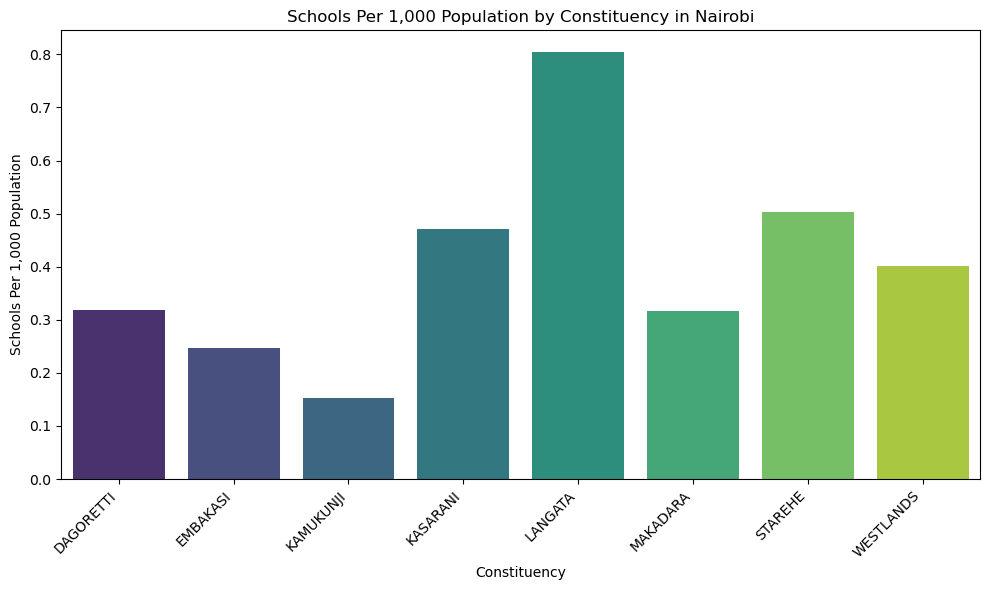

In [25]:
##Visualize disparities using bar plots
plt.figure(figsize=(10, 6))
sns.barplot(data=school_distribution, x="Constituency", y="Schools_Per_1000_Pop", palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Schools Per 1,000 Population by Constituency in Nairobi")
plt.ylabel("Schools Per 1,000 Population")
plt.xlabel("Constituency")
plt.tight_layout()
plt.show()

To wrap up the analysis, I sorted constituencies by their school-to-population ratio. This revealed a clear infrastructure gap in areas like Kamukunji and Makadara, where access to schools is lowest relative to population. These areas should be prioritized in future education planning.

In [26]:
##Map infrastructure gaps
infrastructure_gaps = school_distribution.sort_values("Schools_Per_1000_Pop").reset_index()
print(infrastructure_gaps)

   index Constituency  School_Count  Population_Total  Schools_Per_1000_Pop
0      2    KAMUKUNJI            41            268276              0.152828
1      1     EMBAKASI           245            988808              0.247773
2      5     MAKADARA            60            189536              0.316563
3      0    DAGORETTI           138            434208              0.317820
4      7    WESTLANDS           124            308854              0.401484
5      3     KASARANI           368            780656              0.471398
6      6      STAREHE           106            210423              0.503747
7      4      LANGATA           159            197489              0.805108


To conclude, I displayed a summary of the most underserved and best-served constituencies based on school-to-population ratios. I also highlighted the most densely populated areas, which face the greatest pressure on infrastructure. This makes it easy to communicate where resources should be prioritized.

In [27]:
# Display results
print("Highest School-to-Population Ratios:")
print(highest_ratio)

print("\nLowest School-to-Population Ratios:")
print(lowest_ratio)

print("\nHighest Population Density Constituencies:")
print(highest_density)

Highest School-to-Population Ratios:
  Constituency  School_Count  Population_Total  Schools_Per_1000_Pop
4      LANGATA           159            197489              0.805108
6      STAREHE           106            210423              0.503747
3     KASARANI           368            780656              0.471398
7    WESTLANDS           124            308854              0.401484
0    DAGORETTI           138            434208              0.317820

Lowest School-to-Population Ratios:
  Constituency  School_Count  Population_Total  Schools_Per_1000_Pop
2    KAMUKUNJI            41            268276              0.152828
1     EMBAKASI           245            988808              0.247773
5     MAKADARA            60            189536              0.316563
0    DAGORETTI           138            434208              0.317820
7    WESTLANDS           124            308854              0.401484

Highest Population Density Constituencies:
  Constituency  Total_Pop  Male_Pop  Femal_Pop   Sex_R

### GENERATING A LIVE MAP TO SHOW DISTRIBUTION OF SCHOOLS IN NAIROBI 

To enable spatial visualization and mapping, I converted the merged dataset into a GeoDataFrame using the school coordinates. This allows me to overlay school locations on constituency boundaries or perform geospatial analysis like clustering or distance-based queries.

In [28]:
# Map constituency boundaries to the school data
geo_schools = gpd.GeoDataFrame(merged_df, geometry=gpd.points_from_xy(merged_df['X'], merged_df['Y']))

I first grouped the GeoDataFrame to count the number of schools per constituency. I then merged that with population data from the census and calculated the number of schools per 1,000 residents. This sets the stage for a choropleth map showing educational access across Nairobi.
It’s a key data transformation step that turns multiple sources into one spatially-aware dataset for geovisualization.

In [29]:
# Aggregate school counts and join with constituency boundaries
school_counts = geo_schools.groupby("Constituency").size().reset_index(name="School_Count")
school_counts = pd.merge(school_counts, census_df, on="Constituency", how="inner")
school_counts["Schools_Per_1000_Pop"] = (school_counts["School_Count"] / school_counts["Total_Pop"]) * 1000

To visualize education access across Nairobi constituencies, I loaded the GeoJSON file containing Kenya’s administrative boundaries using geopandas. This gives me the polygon geometry for each region, which I can then join with my education metrics for mapping.

In [30]:
nairobi_boundaries = gpd.read_file('kenya_geojson')

To enable choropleth mapping, I joined my education access metrics with the geographic boundaries of Nairobi constituencies. I ensured column names were consistent and used a left merge to preserve all spatial features. This gave me a spatially-enabled dataset where each region carries relevant infrastructure metrics.
This allows me to map disparities visually, reinforcing the data-driven story with clear regional context

In [31]:
# Merge with Nairobi boundaries
nairobi_boundaries["Constituency"] = nairobi_boundaries["CONSTITUEN"].str.strip().str.upper()
geo_merged = nairobi_boundaries.merge(school_counts, on="Constituency", how="left")

I used Folium to build an interactive map showing school distribution across Nairobi. Each constituency polygon displays the number of schools and their per capita access. Individual school markers allow users to explore exact locations. This makes infrastructure gaps more intuitive and actionable for planning or advocacy.
Saving it as an HTML file makes it easy to share with non-technical audiences like policy teams or education planners.

In [32]:
# Visualize with Folium
#Initializes a Folium map centered on Nairobi (approximate coordinates).zoom_start=12 gives a city-wide view — ideal for plotting multiple regions.
# Base map
m = folium.Map(location=[-1.286389, 36.817223], zoom_start=12)

# Add constituency boundaries
folium.GeoJson(
    geo_merged,
    style_function=lambda x: {'fillColor': 'green', 'color': 'black', 'weight': 0.5, 'fillOpacity': 0.5},
    tooltip=folium.GeoJsonTooltip(fields=["Constituency", "School_Count", "Schools_Per_1000_Pop"], aliases=["Constituency", "Schools", "Schools/1k Pop"])
).add_to(m)

# Add school locations
for _, row in geo_schools.iterrows():
    folium.Marker(
        location=[row['Y'], row['X']],
        popup=row['Name_of_Sc']
    ).add_to(m)

# Save map to HTML
m.save('nairobi_schools_map.html')

# Display Map
m

## Findings
1. Pupil Teacher Ratio are higher in areas such as Kamukunji followed by Makadara and Starehe
2. Classroom to students ratio are higher in starehe, Kamukunji and Makadara
3. Toilet to students ratio are higher in Starehe then Kamukunji
4. Also we have more students not having classrooms in Makadara and Kamukunji


## Recommendations
1. I recommend that the government should construct more schools especially in Kamukunji and Makadara which have a higher population compared to the rest of Nairobi
2. More teachers should be hired in schools especially  Kamukunji , Makadara and Starehe 
3. Building of Ammenities and Classrooms should also take place in the same areas Kamukunji,Starehe and Makadara
4. Target high-density, underserved areas for new schools.
5. Partnerships:Leverage community and NGO support for ongoing improvements.
